In [ ]:
# Bloque 1: Importar librerías
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Librerías importadas correctamente.")
print(f"Versión de TensorFlow: {tf.__version__}")

Librerías importadas correctamente.
Versión de TensorFlow: 2.19.0


In [ ]:
# Cargar y preparar el dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Seleccionar la característica (Ingreso Medio) y el objetivo (Precio)
X = df[['MedInc']].values
y = df['MedHouseVal'].values

# CORRECCIÓN AQUÍ: Cambiamos 'test_test_split' por 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Forma de X_train_scaled: {X_train_scaled.shape}")
print("Datos normalizados y divididos correctamente.")

Forma de X_train_scaled: (16512, 1)
Datos normalizados y divididos correctamente.


In [ ]:
# Bloque 3: Construir el modelo
# Una red con una sola neurona denota regresión lineal: y = w*x + b
model = tf.keras.Sequential([
    layers.Dense(units=1, input_shape=[1]) # 1 entrada, 1 neurona, activación lineal por defecto
])

# Compilar
# Usamos el optimizador Adam (muy común y eficiente) y MSE como pérdida.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'] # MAE es más fácil de interpretar
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Bloque 4: Entrenar
print("Iniciando entrenamiento...")
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,           # Número de iteraciones
    batch_size=32,       # Ajustar pesos cada 32 ejemplos
    validation_split=0.1,# Usar 10% del train para validar internamente
    verbose=1
)

Iniciando entrenamiento...
Epoch 1/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.7190 - mean_absolute_error: 1.0806 - val_loss: 0.7507 - val_mean_absolute_error: 0.6413
Epoch 2/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6978 - mean_absolute_error: 0.6258 - val_loss: 0.7347 - val_mean_absolute_error: 0.6326
Epoch 3/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6959 - mean_absolute_error: 0.6230 - val_loss: 0.7339 - val_mean_absolute_error: 0.6379
Epoch 4/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6962 - mean_absolute_error: 0.6236 - val_loss: 0.7339 - val_mean_absolute_error: 0.6382
Epoch 5/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6960 - mean_absolute_error: 0.6238 - val_loss: 0.7335 - val_mean_absolute_error: 0.6399
Epoch 6/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6970 - mean_absolute_error: 0.6243 - val_loss: 0.7336 - val_mean_absolute_error: 0.6389
Epoch 7/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6969 - mean

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


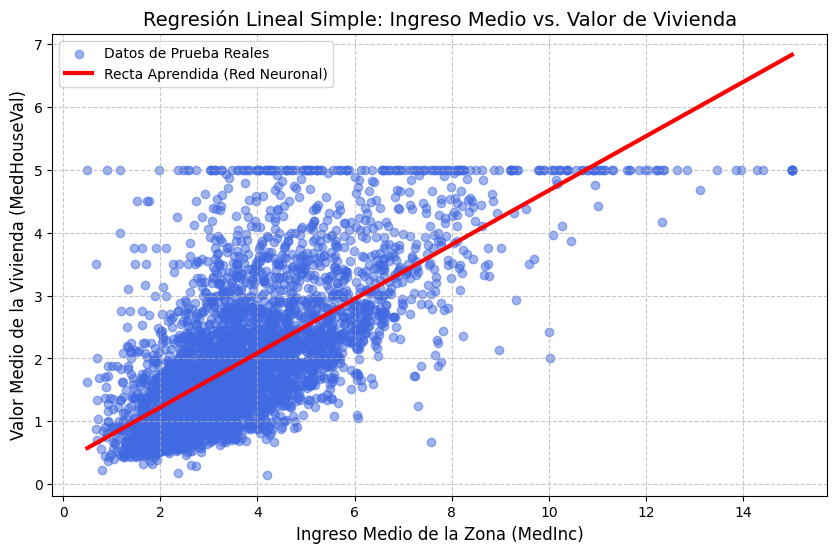

In [ ]:
# Bloque 5: Gráfico de la Regresión Lineal
plt.figure(figsize=(10, 6))

# 1. Graficar los datos reales de PRUEBA (puntos)
plt.scatter(X_test, y_test, color='royalblue', alpha=0.5, label='Datos de Prueba Reales')

# 2. Generar predicciones para la recta de regresión
# Creamos un rango de X normalizado para dibujar la línea continua
X_line = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
X_line_scaled = scaler.transform(X_line) # ¡No olvides escalar la entrada!
y_line_pred = model.predict(X_line_scaled)

# 3. Graficar la línea de regresión aprendida (roja)
plt.plot(X_line, y_line_pred, color='red', linewidth=3, label='Recta Aprendida (Red Neuronal)')

# Ajustes de formato
plt.title('Regresión Lineal Simple: Ingreso Medio vs. Valor de Vivienda', fontsize=14)
plt.xlabel('Ingreso Medio de la Zona (MedInc)', fontsize=12)
plt.ylabel('Valor Medio de la Vivienda (MedHouseVal)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


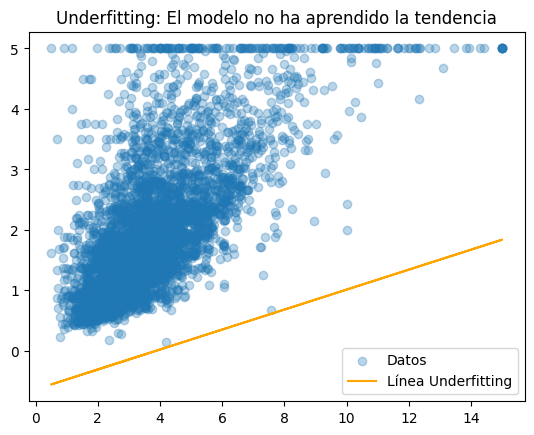

In [ ]:
# --- ESCENARIO 1: UNDERFITTING ---
model_under = tf.keras.Sequential([layers.Dense(1, input_shape=[1])])
model_under.compile(optimizer=tf.keras.optimizers.Adam(0.000001), loss='mse') # LR casi nulo

# Entrenamos solo 1 época: el modelo no aprende nada
history_under = model_under.fit(X_train_scaled, y_train, epochs=1, verbose=0)

# Graficar resultado
plt.scatter(X_test, y_test, alpha=0.3, label='Datos')
plt.plot(X_test, model_under.predict(X_test_scaled), color='orange', label='Línea Underfitting')
plt.title("Underfitting: El modelo no ha aprendido la tendencia")
plt.legend()
plt.show()

In [ ]:
# --- ESCENARIO 2: OVERFITTING ---
model_over = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=[1]),
    layers.Dense(128, activation='relu'),
    layers.Dense(1)
])
model_over.compile(optimizer='adam', loss='mse')

# Entrenamos por muchas épocas (ej. 200) para forzar el sobreajuste
history_over = model_over.fit(X_train_scaled, y_train, epochs=200, validation_split=0.2, verbose=0)

print("Entrenamiento de Overfitting completado.")

Entrenamiento de Overfitting completado.


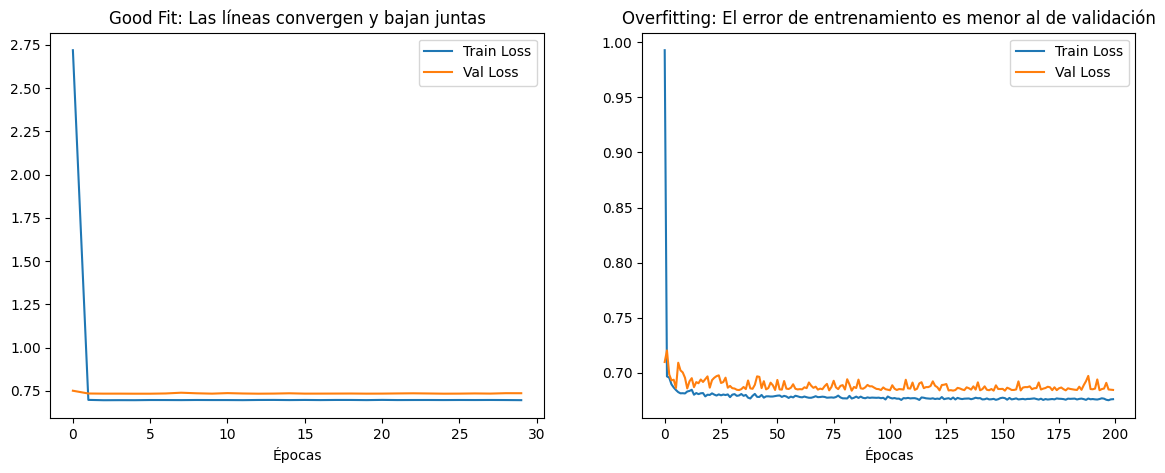

In [ ]:
# --- COMPARATIVA DE CURVAS DE APRENDIZAJE ---
plt.figure(figsize=(14, 5))

# Gráfico del modelo entrenado correctamente (el del Bloque 4 original)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Good Fit: Las líneas convergen y bajan juntas')
plt.xlabel('Épocas')
plt.legend()

# Gráfico del modelo con Overfitting
plt.subplot(1, 2, 2)
plt.plot(history_over.history['loss'], label='Train Loss')
plt.plot(history_over.history['val_loss'], label='Val Loss')
plt.title('Overfitting: El error de entrenamiento es menor al de validación')
plt.xlabel('Épocas')
plt.legend()

plt.show()

In [ ]:
# Bloque 6: Ver los parámetros aprendidos (w y b)
# model.get_weights() devuelve una lista: [weights, bias]
weights = model.get_weights()
w_aprendido = weights[0][0][0]
b_aprendido = weights[1][0]

print("-" * 30)
print(" PARÁMETROS DE INGENIERÍA APRENDIDOS")
print("-" * 30)
print(f"Ecuación aprendida (datos escalados): y = {w_aprendido:.4f} * x_scaled + {b_aprendido:.4f}")
print("-" * 30)

------------------------------
 PARÁMETROS DE INGENIERÍA APRENDIDOS
------------------------------
Ecuación aprendida (datos escalados): y = 0.8218 * x_scaled + 2.0336
------------------------------
